Using device: cpu
총 10개의 파일 발견. 통합 데이터 로드 시작...
데이터 스케일링 진행 중...
로드 완료 -> 정상 데이터 수: 13484708, 공격 데이터 수: 2748294

========= DQN 기반 NIDS 학습 시작 =========
에피   1/800 | 보상: -1060.0 | 정확도:  49.0% | 오탐율(FPR):  50.0% | 미탐율(FNR):  52.0% | 공격비율:  50.0% | 입실론: 1.000
에피   5/800 | 보상:  -978.0 | 정확도:  51.3% | 오탐율(FPR):  47.2% | 미탐율(FNR):  50.2% | 공격비율:  50.0% | 입실론: 0.984
에피  10/800 | 보상:  -880.0 | 정확도:  51.8% | 오탐율(FPR):  50.6% | 미탐율(FNR):  45.8% | 공격비율:  50.0% | 입실론: 0.965
에피  15/800 | 보상:  -930.0 | 정확도:  51.9% | 오탐율(FPR):  47.8% | 미탐율(FNR):  48.4% | 공격비율:  50.0% | 입실론: 0.945
에피  20/800 | 보상:  -800.0 | 정확도:  54.6% | 오탐율(FPR):  46.2% | 미탐율(FNR):  44.6% | 공격비율:  50.0% | 입실론: 0.927
에피  25/800 | 보상:  -850.0 | 정확도:  54.7% | 오탐율(FPR):  43.4% | 미탐율(FNR):  47.2% | 공격비율:  50.0% | 입실론: 0.908
에피  30/800 | 보상:  -712.0 | 정확도:  57.4% | 오탐율(FPR):  42.2% | 미탐율(FNR):  43.0% | 공격비율:  50.0% | 입실론: 0.890
에피  35/800 | 보상:  -806.0 | 정확도:  54.7% | 오탐율(FPR):  45.6% | 미탐율(FNR):  45.0% | 공격비율:  50.0% | 입실론: 0.873
에피  40/80

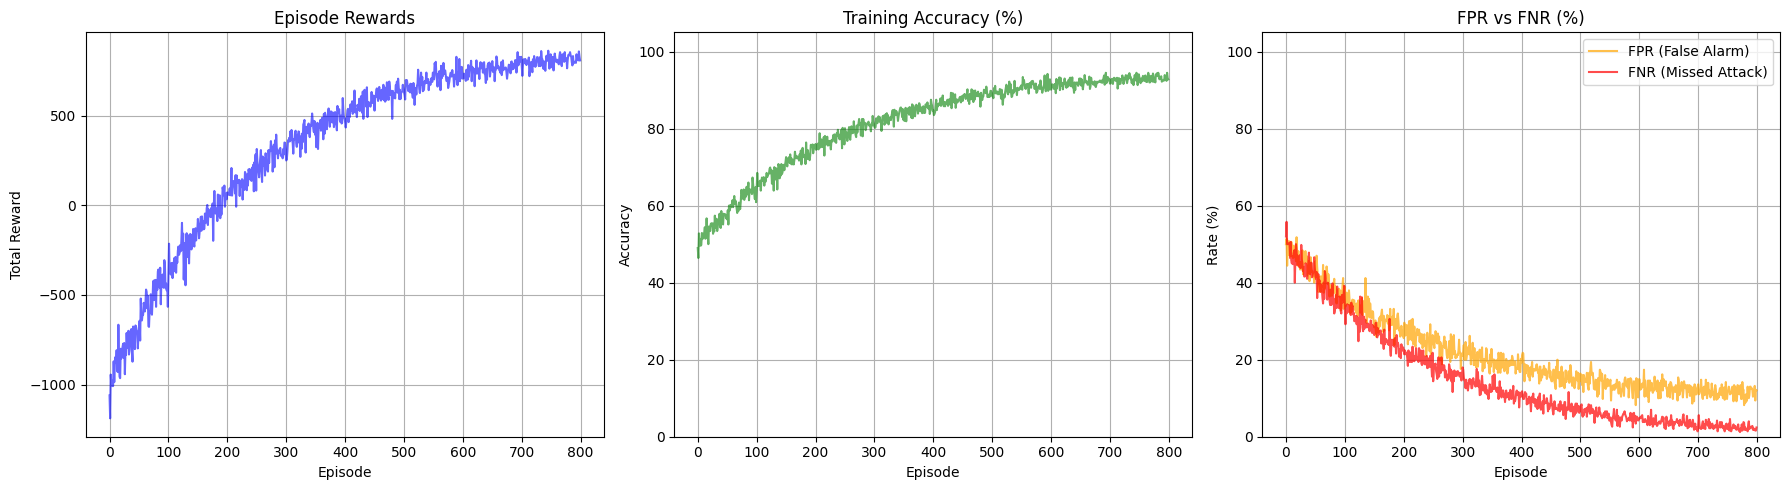

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. NIDS 강화학습 환경
# ==========================================
class NIDSEnv(gym.Env):
    def __init__(self, folder_path, max_steps=1000):
        super(NIDSEnv, self).__init__()
        
        file_list = glob.glob(os.path.join(folder_path, "*.csv"))
        if not file_list:
            raise FileNotFoundError(f"경로에 CSV 파일이 없습니다: {folder_path}")
        
        print(f"총 {len(file_list)}개의 파일 발견. 통합 데이터 로드 시작...")
        
        X_list = []
        y_list = []
        
        for file in file_list:
            df = pd.read_csv(file, low_memory=False)
            X_sub = df.drop(columns=['Label', 'Timestamp'], errors='ignore')
            X_sub = X_sub.select_dtypes(include=[np.number]).astype(np.float32)
            y_sub = df['Label'].apply(lambda x: 0 if str(x).strip() == 'Benign' else 1).values.astype(np.int8)
            
            X_list.append(X_sub)
            y_list.append(y_sub)
            
        self.X = pd.concat(X_list, ignore_index=True)
        self.y = np.concatenate(y_list, axis=0)
        del X_list, y_list
        
        X_np = self.X.to_numpy(dtype=np.float32)
        X_np[np.isinf(X_np)] = np.nan
        col_means = np.nanmean(X_np, axis=0)
        col_means = np.nan_to_num(col_means, nan=0.0)
        
        inds = np.where(np.isnan(X_np))
        X_np[inds] = np.take(col_means, inds[1])
        
        np.clip(X_np, a_min=0, a_max=None, out=X_np)
        X_log = np.log1p(X_np)
        del X_np
        
        print("데이터 스케일링 진행 중...")
        scaler = MinMaxScaler()
        self.X_scaled = scaler.fit_transform(X_log)
        del X_log
        
        self.total_rows = len(self.y)
        self.max_steps = max_steps
        self.current_step = 0
        
        self.benign_indices = np.where(self.y == 0)[0]
        self.attack_indices = np.where(self.y == 1)[0]
        
        print(f"로드 완료 -> 정상 데이터 수: {len(self.benign_indices)}, 공격 데이터 수: {len(self.attack_indices)}")
        if len(self.attack_indices) == 0:
            raise ValueError("데이터셋 내에 공격(Attack) 데이터가 존재하지 않습니다. 파일을 확인해주세요.")
        
        self.episode_indices = []
        
        num_features = self.X_scaled.shape[1]
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(num_features,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        
        half_steps = self.max_steps // 2
        sampled_benign = np.random.choice(self.benign_indices, half_steps, replace=True)
        sampled_attack = np.random.choice(self.attack_indices, half_steps, replace=True)
        
        self.episode_indices = np.concatenate([sampled_benign, sampled_attack])
        np.random.shuffle(self.episode_indices)
        
        state = self.X_scaled[self.episode_indices[self.current_step]].astype(np.float32)
        info = {}
        return state, info

    def step(self, action):
        actual_label = self.y[self.episode_indices[self.current_step]]
        
        if action == actual_label:
            reward = 1.0  
        else:
            if actual_label == 1 and action == 0:
                reward = -5.0  # 미탐 패널티 (실제 공격인데 통과시킨 경우)
            else:
                reward = -1.0  # 오탐 패널티 (정상인데 공격으로 오판한 경우)
        
        self.current_step += 1
        terminated = self.current_step >= self.max_steps
        truncated = False
        
        if not terminated:
            next_state = self.X_scaled[self.episode_indices[self.current_step]].astype(np.float32)
        else:
            next_state = np.zeros(self.observation_space.shape, dtype=np.float32)
            
        info = {"actual": actual_label, "predicted": action}
        return next_state, reward, terminated, truncated, info

# ==========================================
# 2. DQN 아키텍처
# ==========================================
class StandardQNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(StandardQNetwork, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        
    def forward(self, x):
        return self.network(x)

# ==========================================
# 3. 에이전트
# ==========================================
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        
        self.policy_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net = StandardQNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.00025)
        self.memory = deque(maxlen=60000)
        
        self.gamma = 0.99
        self.epsilon = 1.0
        
        self.epsilon_decay = 0.996 
        self.epsilon_min = 0.01
        
        self.batch_size = 64
        self.tau = 0.005 
        self.focal_gamma = 2.0

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randint(0, self.action_dim - 1)
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).to(device)
                q_values = self.policy_net(state_t)
                return torch.argmax(q_values).item()

    def store_transition(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return
        
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        states_t = torch.FloatTensor(np.array(states)).to(device)
        actions_t = torch.LongTensor(actions).view(-1, 1).to(device)
        rewards_t = torch.FloatTensor(rewards).view(-1, 1).to(device)
        next_states_t = torch.FloatTensor(np.array(next_states)).to(device)
        dones_t = torch.FloatTensor(dones).view(-1, 1).to(device)
        
        current_q = self.policy_net(states_t).gather(1, actions_t)
        
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(1)[0].view(-1, 1)
            target_q = rewards_t + (self.gamma * max_next_q * (1 - dones_t))
            
        td_error = torch.abs(current_q - target_q)
        
        p_t = torch.exp(-td_error)
        focal_weight = (1 - p_t) ** self.focal_gamma
        
        loss = (focal_weight * nn.MSELoss(reduction='none')(current_q, target_q)).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(self.tau * policy_param.data + (1.0 - self.tau) * target_param.data)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

# ==========================================
# 4. 메인 루프 실행
# ==========================================
if __name__ == "__main__":
    folder_path = r"C:\ids2018_data"
    
    env = NIDSEnv(folder_path=folder_path, max_steps=1000)
    agent = DQNAgent(state_dim=env.observation_space.shape[0], action_dim=env.action_space.n)
    
    num_episodes = 800 
    
    history_rewards = []
    history_accuracy = []
    history_fpr = []
    history_fnr = []
    
    print("\n========= DQN 기반 NIDS 학습 시작 =========")
    for episode in range(num_episodes):
        state, info = env.reset()
        episode_reward = 0
        tp, tn, fp, fn = 0, 0, 0, 0
        
        for step in range(env.max_steps):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            agent.store_transition(state, action, reward, next_state, done)
            agent.train_step()
            
            episode_reward += reward
            state = next_state
            
            act = info["actual"]
            pred = info["predicted"]
            
            if act == 1 and pred == 1: tp += 1
            elif act == 0 and pred == 0: tn += 1
            elif act == 0 and pred == 1: fp += 1
            elif act == 1 and pred == 0: fn += 1
                
            if done:
                break
                
        accuracy = ((tp + tn) / env.max_steps) * 100
        fpr = (fp / (fp + tn)) * 100 if (fp + tn) > 0 else 0.0
        fnr = (fn / (fn + tp)) * 100 if (fn + tp) > 0 else 0.0
        attack_ratio = ((tp + fn) / env.max_steps) * 100
        
        history_rewards.append(episode_reward)
        history_accuracy.append(accuracy)
        history_fpr.append(fpr)
        history_fnr.append(fnr)
        
        if (episode + 1) % 5 == 0 or episode == 0:
            print(f"에피 {episode+1:3d}/{num_episodes} | "
                  f"보상: {episode_reward:7.1f} | "
                  f"정확도: {accuracy:5.1f}% | "
                  f"오탐율(FPR): {fpr:5.1f}% | "
                  f"미탐율(FNR): {fnr:5.1f}% | "
                  f"공격비율: {attack_ratio:5.1f}% | "
                  f"입실론: {agent.epsilon:.3f}")
        
        agent.decay_epsilon()
            
    print("========= 학습 완료 =========")
    
    # ==========================================
    # 5. 결과 시각화 그래프 출력
    # ==========================================
    plt.figure(figsize=(18, 5))

    # 누적 보상 그래프
    plt.subplot(1, 3, 1)
    plt.plot(history_rewards, color='blue', alpha=0.6)
    plt.title('Episode Rewards')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)

    # 정확도 그래프
    plt.subplot(1, 3, 2)
    plt.plot(history_accuracy, color='green', alpha=0.6)
    plt.title('Training Accuracy (%)')
    plt.xlabel('Episode')
    plt.ylabel('Accuracy')
    plt.ylim(0, 105)
    plt.grid(True)

    # 오탐율 & 미탐율 비교 그래프
    plt.subplot(1, 3, 3)
    plt.plot(history_fpr, label='FPR (False Alarm)', color='orange', alpha=0.7)
    plt.plot(history_fnr, label='FNR (Missed Attack)', color='red', alpha=0.7)
    plt.title('FPR vs FNR (%)')
    plt.xlabel('Episode')
    plt.ylabel('Rate (%)')
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()